In [149]:
import numpy as np
import matplotlib.pyplot as plt
import PhysicalConstantsCGS as const
import pandas as pd

### Plot the ISM equilibrium curves for different Z

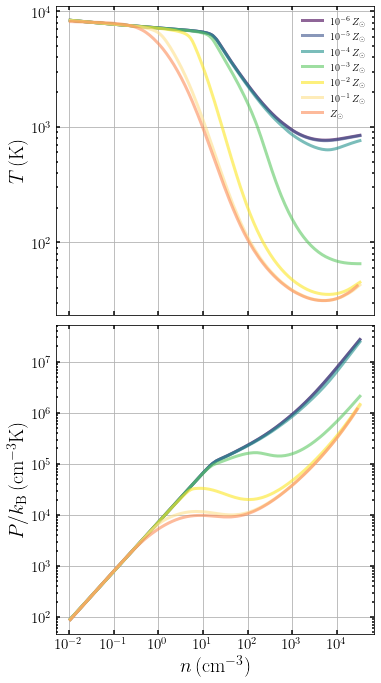

In [262]:
fig, axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6),tight_layout=True)

Zvals = [-6,-5,-4,-3,-2,-1,0]
labels = [r"$10^{-6} \, Z_{\odot}$",r"$10^{-5} \, Z_{\odot}$", r"$10^{-4} \, Z_{\odot}$",r"$10^{-3} \, Z_{\odot}$",r"$10^{-2} \, Z_{\odot}$",r"$10^{-1} \, Z_{\odot}$",r"$ Z_{\odot}$"]
#colors from viridis colorbar
colors = ['#440154','#3B528B','#21918C','#5DC863','#FDE725','#FEE08B','#FC8D59']

for i,Z in enumerate(Zvals):
    data = np.loadtxt('AB_Z'+str(Z)).T
    axs[0].plot(data[0],data[1],label=labels[i],lw=3.0,alpha=0.6,color=colors[i])
    axs[1].plot(data[0],data[0]*data[1],lw=3.0,alpha=0.6,color=colors[i])

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[0].grid()
axs[1].grid()
axs[0].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4])
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')
axs[1].set_ylabel(r'$P/k_{\rm B} \, (\mathrm{cm}^{-3} \mathrm{K})$')
axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[0].legend()

fig.savefig('ISMEq_Z.pdf',bbox_inches='tight')


## Equilibrium curves and abundances

In [179]:
def get_Hnuclei(file):
    ab = open(file,'r')
    f = np.loadtxt(file).T
    header = ab.readline()
    headers = header.split("#")[1].split("\n")[0].split(" ")
    nHnuclei = 0.0
    cols = int(np.shape(f)[0])
    for i in range(2,cols):
        if(headers[i] == "H"):
            nHnuclei += f[i]
        elif(headers[i] == "H2"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H-"):
            nHnuclei += f[i]
        elif(headers[i] == "HD"):
            nHnuclei += f[i]
        elif(headers[i] == "OH"):
            nHnuclei += f[i]
        elif(headers[i] == "CH"):
            nHnuclei += f[i]
        elif(headers[i] == "CH2"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "CH3"):
            nHnuclei += f[i] * 3.0
        elif(headers[i] == "CH4"):
            nHnuclei += f[i] * 4.0
        elif(headers[i] == "H20_total"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H+"):
            nHnuclei += f[i]
        elif(headers[i] == "H2+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "HD+"):
            nHnuclei += f[i]
        elif(headers[i] == "OH+"):
            nHnuclei += f[i]
        elif(headers[i] == "H20+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H30+"):
            nHnuclei += f[i] * 3.0
        elif(headers[i] == "CH+"):
            nHnuclei += f[i]
        elif(headers[i] == "CH2+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H3+"):
            nHnuclei += f[i] * 3.0

    return nHnuclei
        
           


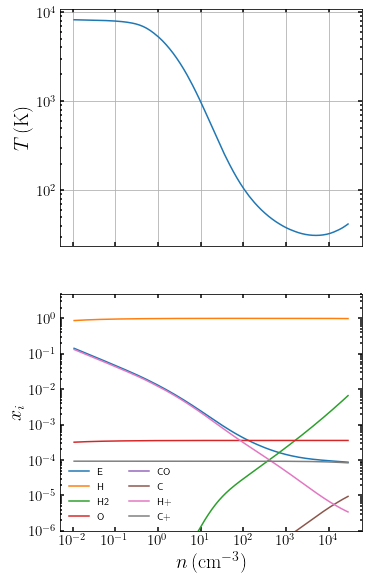

In [259]:
fig, axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6))

f = np.loadtxt('AB_Z0').T

axs[0].plot(f[0],f[1])
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4])
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')

axs[0].grid()

ab = open('AB_Z0','r')
header = ab.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")
filters = ["E","H","H+","H2","O","CO","C","C+"]
cols = int(np.shape(f)[0])

#Get H nuclei
nHnuclei = get_Hnuclei('AB_Z0')

for i in range(2,cols):
    if(headers[i] in filters):
        axs[1].plot(f[0],f[i]/nHnuclei,label=str(headers[i]))

axs[1].legend(ncol=2)
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[1].set_ylabel(r'$x_{i}$')
axs[1].set_ylim(1.e-6,5.0)

#fig.savefig('Fig.pdf',bbox_inches='tight')


## Compare to Kim+23 and other studies

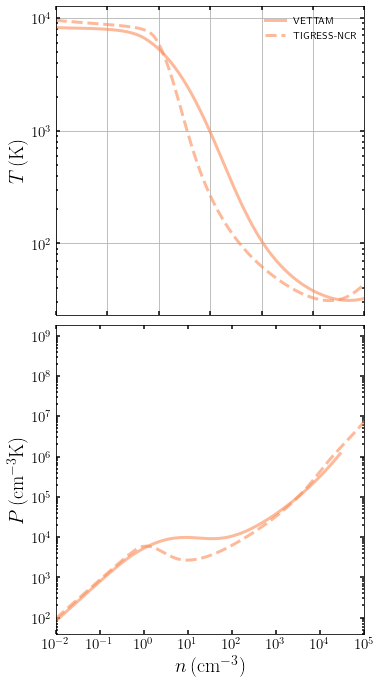

In [253]:
fig,axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6),tight_layout=True)

f = np.loadtxt('AB_Z0').T

color = '#FC8D59'

axs[0].plot(f[0],f[1],color=color,lw=3.0,alpha=0.6,label="VETTAM")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')

axs[1].plot(f[0],f[0]*f[1],color=color,lw=3.0,alpha=0.6)

#Overplot Kim+ plot
fname = "/Users/shm/Desktop/noshld_zg0.0_zd0.0_xi0.00.txt"
df = pd.read_csv(fname, sep='\s+')
df['T'] = df['pok']/(df['nH']*(1.1 + df['xe'] - df['xH2']))

axs[0].plot(df['nH'],df['T'],lw=3.0,alpha=0.6,ls='dashed',color=color,label="TIGRESS-NCR")
axs[1].plot(df['nH'],df['nH']*df['T'],lw=3.0,alpha=0.6,ls='dashed',color=color)
axs[0].grid()

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[1].set_ylabel(r'$P \, (\mathrm{cm}^{-3} \mathrm{K})$')
axs[1].set_xlim(1.e-2,1.e4)
axs[1].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4,1.e5])
axs[1].set_yscale('log')

axs[0].legend()

#fig.savefig('VETTAM_TIGRESS.pdf',bbox_inches='tight')

### Plot cooling functions

In [42]:
f = np.loadtxt('fort.31').T
np.shape(f)[0]

27

### Plot heating and cooling terms

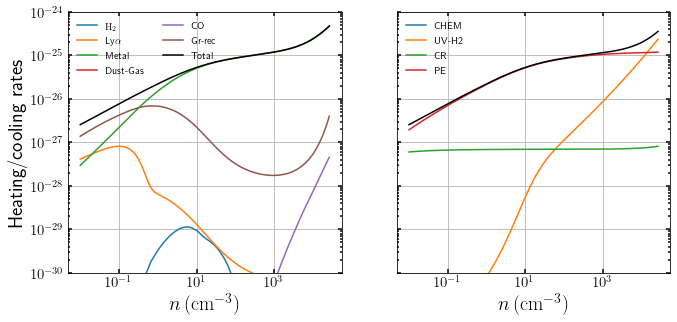

In [263]:
fig,axs = plt.subplots(ncols=2,figsize=(10.8,4.8),sharey=True)

f = np.loadtxt('AB_Z0').T
nH = get_Hnuclei('AB_Z0')

f = np.loadtxt('COOL_Z0').T
ngas = f[0]
cols = int(np.shape(f)[0])
cool = open('COOL_Z0','r')
header = cool.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")

filters = ["ATOMIC","H2","Z","CO","DUST","DUSTGRREC"]
labels = ["Ly" + r"$\alpha$",r"$\rm{H}_2$","Metal","CO","Dust-Gas","Gr-rec"]

#ind = 0
for i in range(3,cols):
    if(headers[i] in filters):
        ind = np.where(np.array(filters) == headers[i])[0][0]        
        axs[0].plot(ngas,f[i]/nH,label=str(labels[ind]))
        #ind = ind+1

axs[0].plot(ngas,f[2]/nH,label='Total',c='k')

axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[0].set_ylabel('Heating/cooling rates')
axs[0].legend(ncol=2)

f = np.loadtxt('HEAT_Z0').T
ngas = f[0]
cols = int(np.shape(f)[0])
heat = open('HEAT_Z0','r')
header = heat.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")

#Heating rates: chemical, compression, photodissociation/ionization, cosmic ray heating, photoelectric heating
filters = ["CHEM","AV","CR","DUST"]
labels = ["CHEM","UV-H2","CR","PE"]

ind = 0
for i in range(3,cols):
    if(headers[i] in filters):
        ind = np.where(np.array(filters) == headers[i])[0][0] 
        axs[1].plot(ngas,f[i]/nH,label=str(labels[ind]))

axs[1].plot(ngas,f[2]/nH,c='k')

axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')

axs[0].set_ylim(1.e-30,1.e-24)

axs[0].grid()
axs[1].grid()

fig.savefig('HeatingCooling.pdf',bbox_inches='tight')



(1e-35, 1e-18)

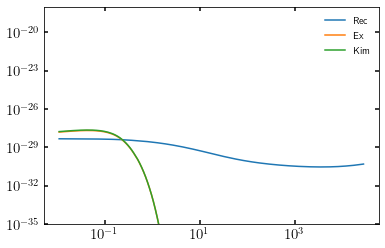

In [139]:
#Check Ly-alpha cooling

#Get n and T
f = np.loadtxt('fort.22').T
ndens, temp = f[0], f[1]

#Get xe and xH+
ne, nHp,nH = f[2], f[23], f[5]

#Get recombination cooling rate
cooling = 8.7e-27*np.sqrt(temp)*(temp/1.e3)**(-0.2)/(1.0+(temp/1.e6)**0.7)*ne*nHp

#collisional excitation rate
cooling_ex = 7.5e-19/(1.e0+np.sqrt(temp/1.e5))*np.exp(-1.18348e5/temp)*ne*nH

#Ly-alpha Kim
T4 = temp/1.e4
Lya = 5.31e-8 * (T4)**(0.15)/(1+(T4/5)**0.65) * np.exp(-11.84/T4) * 1.184e5 * const.k_BoltzmannConstant * ne*nH

plt.plot(ndens,cooling/nH,label='Rec')
plt.plot(ndens,cooling_ex/nH,label='Ex')
plt.plot(ndens,Lya/nH,label='Kim')
plt.yscale('log')
plt.xscale('log')

plt.legend()
plt.ylim(1.e-35,1.e-18)


### Checking convergence with tolerance

Text(0, 0.5, '$T \\, (\\mathrm{K})$')

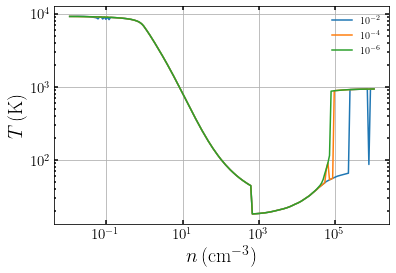

In [38]:
files = ["fort1e-2.22","fort1e-4.22","fort1e-6.22"]
labels = [r"$10^{-2}$",r"$10^{-4}$",r"$10^{-6}$"]
for i,file in enumerate(files):
    f = np.loadtxt(file).T
    plt.plot(f[0],f[1],label=labels[i])
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.xlabel(r'$n \, (\mathrm{cm}^{-3})$')
plt.ylabel(r'$T \, (\mathrm{K})$')